<a href="https://colab.research.google.com/github/debashisdotchatterjee/e-value-CREP-Astronomy-1-CSA/blob/main/P_Value_%26_e_value_Theory_Proposal_Simulation_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

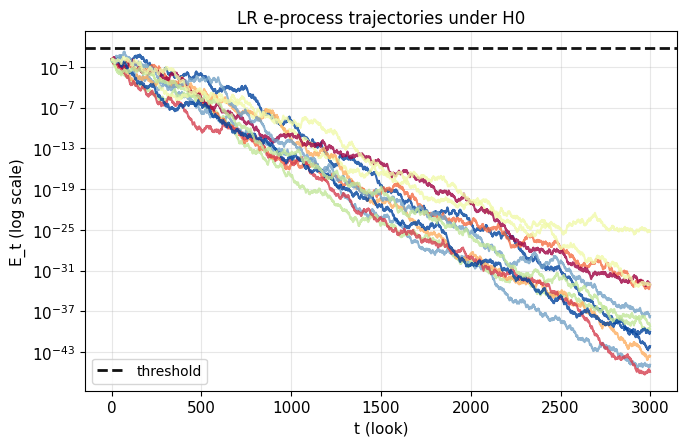

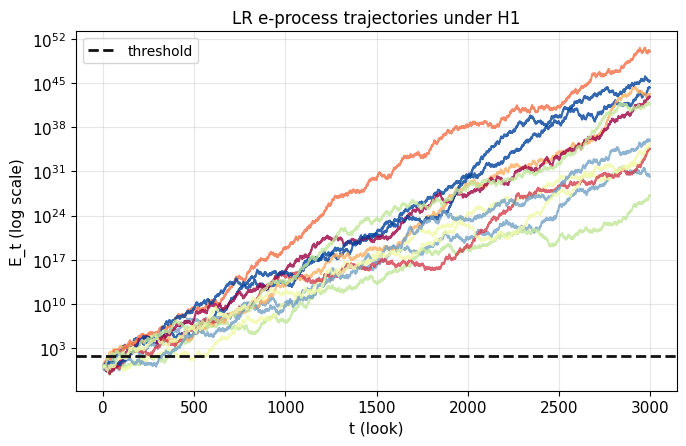

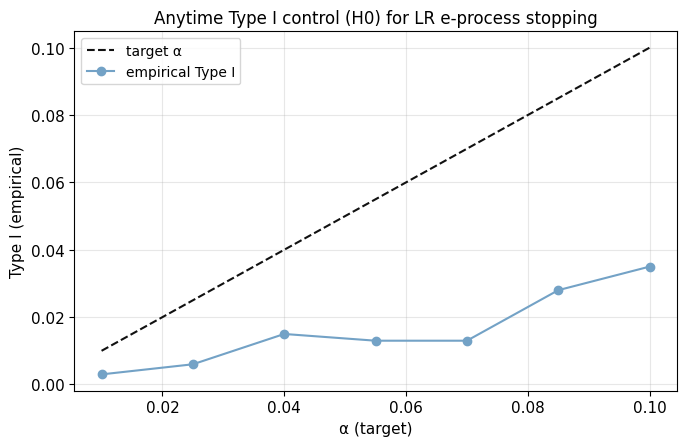

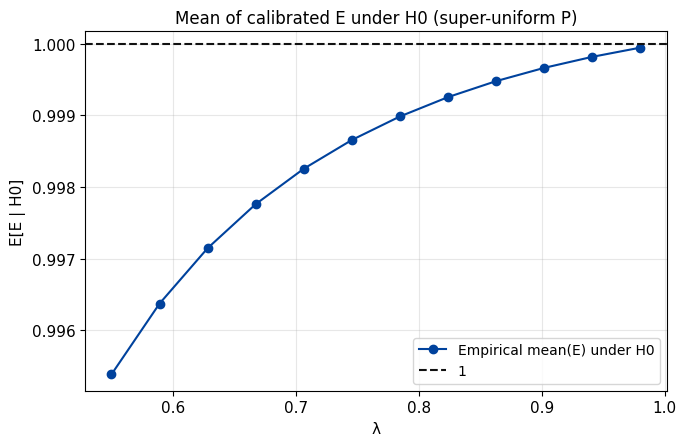

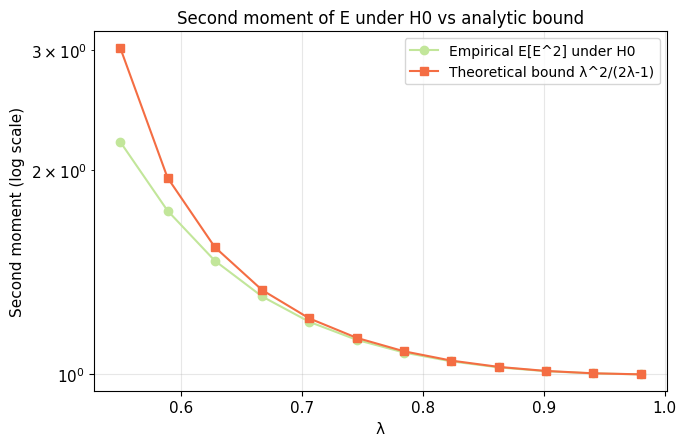

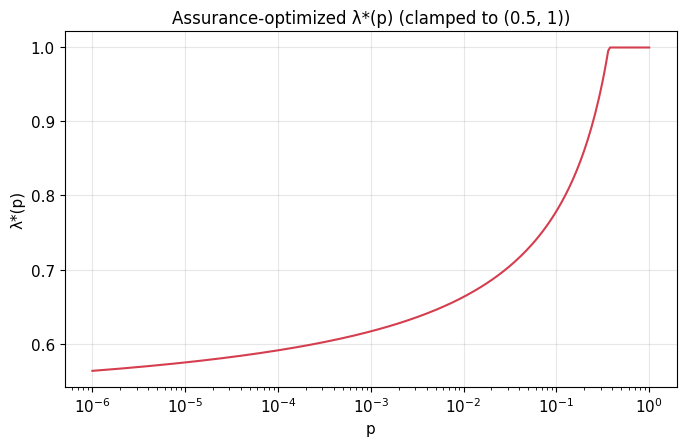

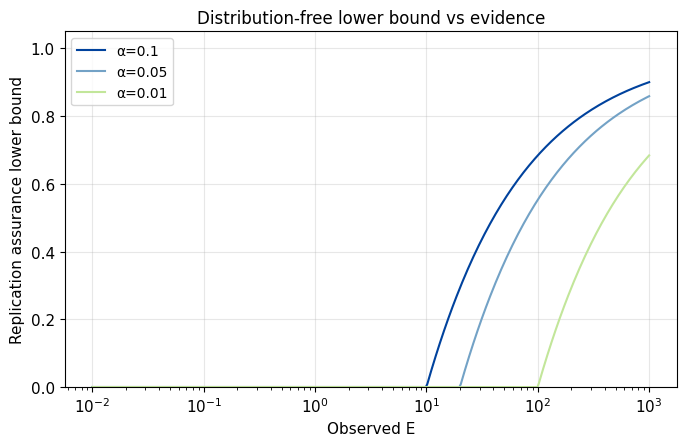

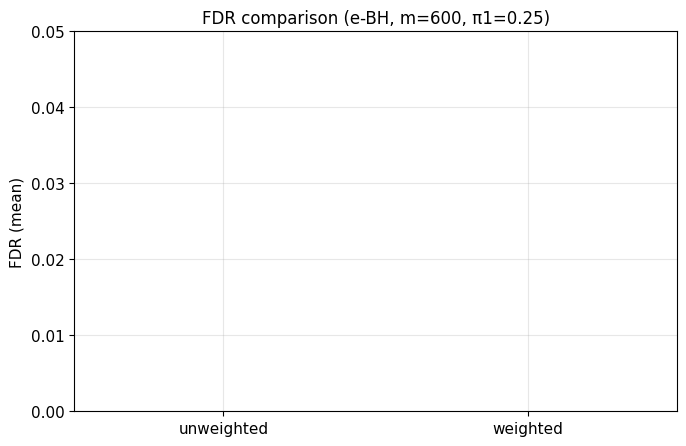

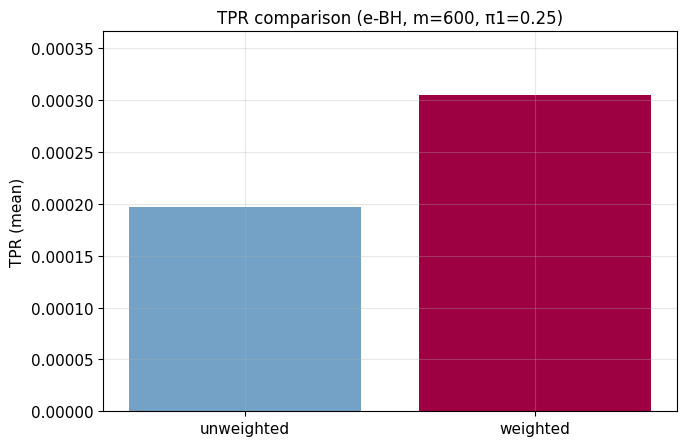

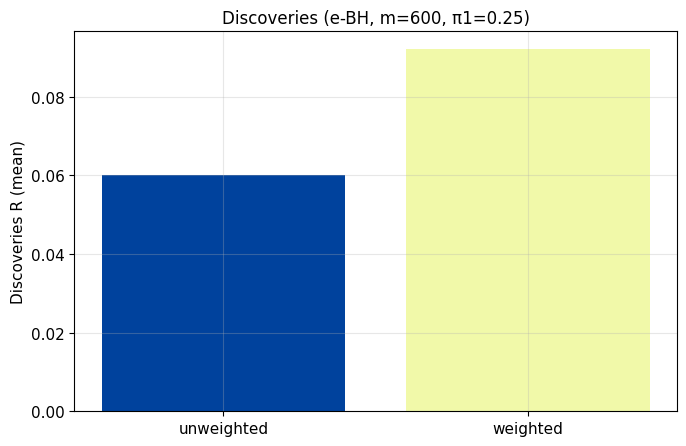

,Metric,Unweighted (mean),Weighted (mean)
0,FDR,0.000000,0.000000
1,TPR,0.000197,0.000305
2,R,0.060000,0.092000


Wrote: data/tables/ebh_summary.csv


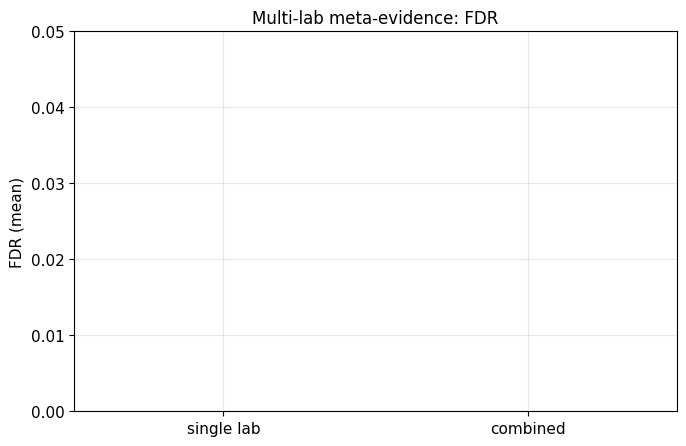

/tmp/ipython-input-2741082980.py:430: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(0, min(1.0, float(max(tpr_vals))*1.2))


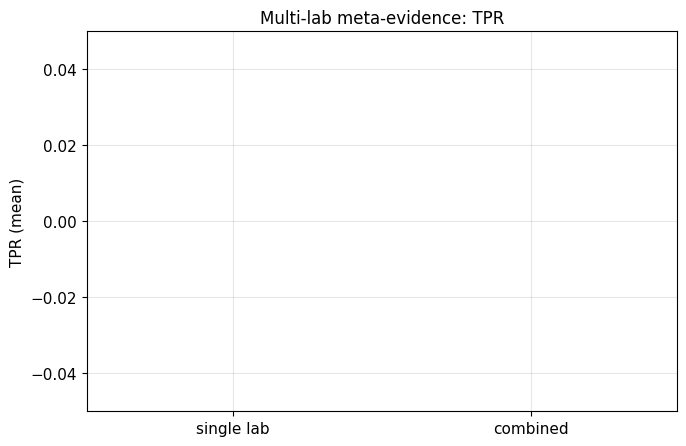

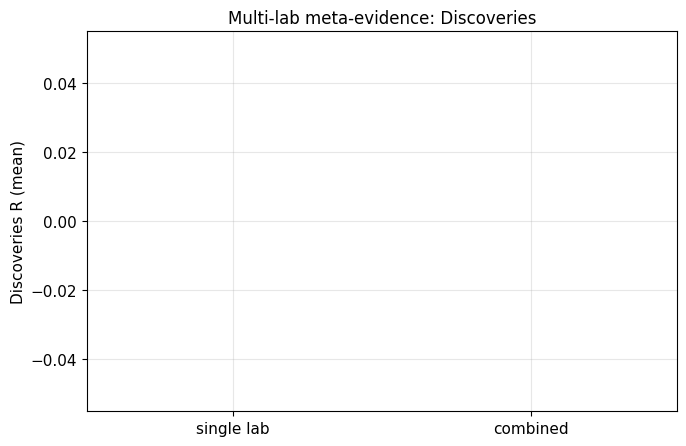

,Metric,Single lab (mean),Combined (mean)
0,FDR,0.0,0.0
1,TPR,0.0,0.0
2,R,0.0,0.0


Wrote: data/tables/meta_summary.csv


/tmp/ipython-input-2741082980.py:113: RuntimeWarning: Mean of empty slice
  mean_T0 = np.nanmean(T_H0)


,alpha,rho,theta0,theta1,Type I (H0),Power (H1),Mean T (H0),Mean T (H1),Predicted T (H1)
0,0.02,0.6,0.4,0.50,0.001667,1.0,361.000000,298.373333,289.738167
1,0.02,0.6,0.4,0.52,0.003333,1.0,167.500000,206.258333,201.696504
2,0.02,0.6,0.4,0.55,0.000000,1.0,NaN,127.333333,129.426700
3,0.02,0.8,0.4,0.50,0.006667,1.0,234.500000,249.240000,249.747239
4,0.02,0.8,0.4,0.52,0.005000,1.0,105.333333,175.850000,173.857471
5,0.02,0.8,0.4,0.55,0.010000,1.0,175.166667,112.265000,111.562661
6,0.02,0.9,0.4,0.50,0.010000,1.0,298.333333,236.375000,228.910119
7,0.02,0.9,0.4,0.52,0.010000,1.0,176.500000,158.586667,159.352049
8,0.02,0.9,0.4,0.55,0.003333,1.0,116.000000,108.156667,102.254672
9,0.05,0.6,0.4,0.50,0.005000,1.0,194.666667,237.410000,244.846155


Wrote: data/tables/ab_summary.csv
Zipped to: data/sim_outputs.zip


In [ ]:
# Re-running after state reset (Colab does this sometimes). Creating figures/tables again and zipping.

import os, io, math, zipfile, itertools, textwrap, random
from dataclasses import dataclass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Safe fallback for display_dataframe_to_user (works in Colab/Notebook) ----
try:
    from caas_jupyter_tools import display_dataframe_to_user  # available in some hosted envs
except Exception:
    def display_dataframe_to_user(title, df):
        try:
            from IPython.display import display, HTML
            display(HTML(f"<h3>{title}</h3>"))
            display(df)
        except Exception:
            print(f"\n=== {title} ===\n")
            print(df if hasattr(df, "head") else df)

# ---- Seeds ----
np.random.seed(2025)
random.seed(2025)

# ---- Paths ----
BASE_DIR = "data"  # keep as you had; works in many hosted envs (incl. this one)
FIG_DIR = os.path.join(BASE_DIR, "figs")
TAB_DIR = os.path.join(BASE_DIR, "tables")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

# ---- Matplotlib style ----
plt.rcParams.update({
    "figure.figsize": (7.0, 4.6),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
})

PALETTE = ["#00429d", "#73a2c6", "#c2e69a", "#f1f9a9", "#fdae61", "#f46d43", "#d53e4f", "#9e0142"]

def savefig(name: str):
    base = os.path.join(FIG_DIR, name)
    plt.tight_layout()
    plt.savefig(base + ".png", dpi=160, bbox_inches="tight")
    plt.savefig(base + ".pdf", bbox_inches="tight")
    return base + ".png"

# ---- e-process (Bernoulli) + utilities ----
def bernoulli_lr_eprocess(theta0: float, theta1: float, X: np.ndarray) -> np.ndarray:
    log_terms = X * np.log(theta1 / theta0) + (1 - X) * np.log((1 - theta1) / (1 - theta0))
    log_cumsum = np.cumsum(log_terms)
    return np.exp(log_cumsum)

def KL_bernoulli(theta1: float, theta0: float) -> float:
    t1, t0 = theta1, theta0
    return t1 * np.log(t1 / t0) + (1 - t1) * np.log((1 - t1) / (1 - t0))

def tau_from_rho_alpha(rho: float, alpha: float) -> float:
    return 1.0 / (alpha * (1.0 - np.sqrt(1.0 - rho))**2)

@dataclass
class ABResult:
    alpha: float
    rho: float
    theta0: float
    theta1: float
    n_sims: int
    max_t: int
    typeI_rate: float
    power: float
    mean_T_H0: float
    mean_T_H1: float
    predicted_T_H1: float

def simulate_ab(theta0=0.4, theta1=0.52, alpha=0.05, rho=0.8, n_sims=2000, max_t=10000, seed=None) -> ABResult:
    if seed is not None:
        np.random.seed(seed)
    tau = tau_from_rho_alpha(rho, alpha)
    I = KL_bernoulli(theta1, theta0)
    pred_T = np.log(tau) / I

    T_H0 = []
    hits_H0 = 0
    for _ in range(n_sims):
        X = (np.random.rand(max_t) < theta0).astype(int)
        E_path = bernoulli_lr_eprocess(theta0, theta1, X)
        idx = np.argmax(E_path >= tau)
        if E_path[idx] >= tau:
            hits_H0 += 1
            T_H0.append(idx + 1)
        else:
            T_H0.append(np.nan)

    T_H1 = []
    hits_H1 = 0
    for _ in range(n_sims):
        X = (np.random.rand(max_t) < theta1).astype(int)
        E_path = bernoulli_lr_eprocess(theta0, theta1, X)
        idx = np.argmax(E_path >= tau)
        if E_path[idx] >= tau:
            hits_H1 += 1
            T_H1.append(idx + 1)
        else:
            T_H1.append(np.nan)

    typeI = hits_H0 / n_sims
    power = hits_H1 / n_sims
    mean_T0 = np.nanmean(T_H0)
    mean_T1 = np.nanmean(T_H1)

    return ABResult(alpha, rho, theta0, theta1, n_sims, max_t, typeI, power, mean_T0, mean_T1, pred_T)

def plot_eprocess_trajectories(theta0=0.4, theta1=0.52, alpha=0.05, rho=0.8, n_paths=12, max_t=2000, seed=None):
    if seed is not None:
        np.random.seed(seed)
    tau = tau_from_rho_alpha(rho, alpha)

    # H0
    plt.figure()
    for i in range(n_paths):
        X = (np.random.rand(max_t) < theta0).astype(int)
        E = bernoulli_lr_eprocess(theta0, theta1, X)
        plt.plot(E, color=PALETTE[i % len(PALETTE)], alpha=0.8)
    plt.axhline(tau, color="#111111", linestyle="--", linewidth=2, label="threshold")
    plt.yscale("log")
    plt.xlabel("t (look)")
    plt.ylabel("E_t (log scale)")
    plt.title("LR e-process trajectories under H0")
    plt.legend()
    savefig("ab_eprocess_trajs_H0")
    plt.show()

    # H1
    plt.figure()
    for i in range(n_paths):
        X = (np.random.rand(max_t) < theta1).astype(int)
        E = bernoulli_lr_eprocess(theta0, theta1, X)
        plt.plot(E, color=PALETTE[i % len(PALETTE)], alpha=0.8)
    plt.axhline(tau, color="#111111", linestyle="--", linewidth=2, label="threshold")
    plt.yscale("log")
    plt.xlabel("t (look)")
    plt.ylabel("E_t (log scale)")
    plt.title("LR e-process trajectories under H1")
    plt.legend()
    savefig("ab_eprocess_trajs_H1")
    plt.show()

def plot_alpha_control_curve(theta0=0.4, theta1=0.52, rho=0.8, alphas=None, n_sims=2000, max_t=4000):
    if alphas is None:
        alphas = np.linspace(0.01, 0.1, 7)
    est = []
    for a in alphas:
        res = simulate_ab(theta0, theta1, a, rho, n_sims=n_sims, max_t=max_t)
        est.append([a, res.typeI_rate])
    A = np.array(est)

    plt.figure()
    plt.plot(A[:, 0], A[:, 0], color="#111111", linestyle="--", label="target α")
    plt.plot(A[:, 0], A[:, 1], marker="o", color=PALETTE[1], label="empirical Type I")
    plt.xlabel("α (target)")
    plt.ylabel("Type I (empirical)")
    plt.title("Anytime Type I control (H0) for LR e-process stopping")
    plt.legend()
    savefig("ab_alpha_control")
    plt.show()

# ---- Calibration & assurance ----
def E_from_p(p: np.ndarray, lam: float) -> np.ndarray:
    return lam * np.power(p, lam - 1.0)

def lambda_star_AOC(p: np.ndarray) -> np.ndarray:
    out = np.zeros_like(p)
    for i, pi in enumerate(p):
        pi = max(min(pi, 0.999999), 1e-12)
        val = 0.25 * (1.0 + math.sqrt(1.0 - 8.0 / math.log(pi)))
        val = min(0.999, max(0.5001, val))
        out[i] = val
    return out

def second_moment_bound(lam: float) -> float:
    if lam <= 0.5:
        return np.inf
    return lam**2 / (2.0*lam - 1.0)

def plot_calibration_moments(n=200000, lam_grid=None):
    if lam_grid is None:
        lam_grid = np.linspace(0.55, 0.99, 15)
    P0 = np.random.rand(n)
    means, seconds, bounds = [], [], []
    for lam in lam_grid:
        E0 = E_from_p(P0, lam)
        means.append(np.mean(E0))
        seconds.append(np.mean(E0**2))
        bounds.append(second_moment_bound(lam))

    plt.figure()
    plt.plot(lam_grid, means, marker="o", color=PALETTE[0], label="Empirical mean(E) under H0")
    plt.axhline(1.0, color="#111111", linestyle="--", label="1")
    plt.xlabel("λ")
    plt.ylabel("E[E | H0]")
    plt.title("Mean of calibrated E under H0 (super-uniform P)")
    plt.legend()
    savefig("calibration_mean_under_H0")
    plt.show()

    plt.figure()
    plt.plot(lam_grid, seconds, marker="o", color=PALETTE[2], label="Empirical E[E^2] under H0")
    plt.plot(lam_grid, bounds, marker="s", color=PALETTE[5], label="Theoretical bound λ^2/(2λ-1)")
    plt.yscale("log")
    plt.xlabel("λ")
    plt.ylabel("Second moment (log scale)")
    plt.title("Second moment of E under H0 vs analytic bound")
    plt.legend()
    savefig("calibration_second_moment_bound")
    plt.show()

def plot_lambda_star_vs_p():
    p_grid = np.logspace(-6, -0.000001, 300)
    lam_star = lambda_star_AOC(p_grid)
    plt.figure()
    plt.plot(p_grid, lam_star, color=PALETTE[6])
    plt.xscale("log")
    plt.xlabel("p")
    plt.ylabel("λ*(p)")
    plt.title("Assurance-optimized λ*(p) (clamped to (0.5, 1))")
    savefig("lambda_star_vs_p")
    plt.show()

def plot_assurance_lower_bound_curves(alpha_list=None, E_grid=None):
    if alpha_list is None:
        alpha_list = [0.1, 0.05, 0.01]
    if E_grid is None:
        E_grid = np.logspace(-2, 3, 400)
    plt.figure()
    for i, a in enumerate(alpha_list):
        y = 1.0 - 1.0 / np.sqrt(a * E_grid)
        y = np.maximum(0.0, y)
        plt.plot(E_grid, y, color=PALETTE[i], label=f"α={a}")
    plt.xscale("log")
    plt.ylim(0, 1.05)
    plt.xlabel("Observed E")
    plt.ylabel("Replication assurance lower bound")
    plt.title("Distribution-free lower bound vs evidence")
    plt.legend()
    savefig("assurance_lower_bound_curves")
    plt.show()

# ---- e-BH (weighted vs unweighted) ----
def weighted_bh(pvals, weights, alpha=0.1):
    m = len(pvals)
    order = np.argsort(pvals / weights)
    p_sorted = pvals[order]
    w_sorted = weights[order]
    thresh = (np.arange(1, m+1) / m) * alpha
    crit = p_sorted / w_sorted <= thresh
    if not np.any(crit):
        reject = np.zeros(m, dtype=bool)
    else:
        k = np.max(np.where(crit)[0]) + 1
        cutoff = (k / m) * alpha
        reject = (pvals / weights) <= cutoff
    return reject

def simulate_multiple_testing(m=500, pi1=0.2, beta_weight=1.2, lam=0.8, alpha=0.1, nsims=300):
    Z_samp = np.random.randn(20000)
    gam_grid = np.linspace(0.0, 3.0, 61)
    def mean_logistic(g):
        return np.mean(1 / (1 + np.exp(-g * Z_samp)))
    gamma = min(gam_grid, key=lambda g: abs(mean_logistic(g) - pi1))

    records = []
    for _ in range(nsims):
        Z = np.random.randn(m)
        prob_alt = 1 / (1 + np.exp(-gamma * Z))
        H = (np.random.rand(m) < prob_alt)
        P = np.empty(m)
        a_alt = 0.2
        P[H == 1] = np.random.beta(a_alt, 1, size=np.sum(H == 1))
        P[H == 0] = np.random.rand(np.sum(H == 0))
        E = lam * P**(lam - 1.0)
        pE = np.minimum(1.0, 1.0 / E)
        w = np.exp(beta_weight * Z)
        w = m * w / np.sum(w)

        # Unweighted BH
        order = np.argsort(pE)
        thresh = (np.arange(1, m+1) / m) * alpha
        crit = pE[order] <= thresh
        if np.any(crit):
            k = np.max(np.where(crit)[0]) + 1
            cutoff = (k / m) * alpha
            rej_unw = pE <= cutoff
        else:
            rej_unw = np.zeros(m, dtype=bool)

        # Weighted BH
        rej_w = weighted_bh(pE, w, alpha=alpha)

        V_unw = np.sum((H == 0) & rej_unw)
        R_unw = np.sum(rej_unw)
        T_unw = np.sum((H == 1) & rej_unw)
        fdr_unw = V_unw / R_unw if R_unw > 0 else 0.0
        tpr_unw = T_unw / np.sum(H == 1) if np.sum(H == 1) > 0 else 0.0

        V_w = np.sum((H == 0) & rej_w)
        R_w = np.sum(rej_w)
        T_w = np.sum((H == 1) & rej_w)
        fdr_w = V_w / R_w if R_w > 0 else 0.0
        tpr_w = T_w / np.sum(H == 1) if np.sum(H == 1) > 0 else 0.0

        records.append({
            "FDR_unweighted": fdr_unw, "TPR_unweighted": tpr_unw, "R_unweighted": R_unw,
            "FDR_weighted": fdr_w, "TPR_weighted": tpr_w, "R_weighted": R_w,
        })
    return pd.DataFrame(records)

def plot_fdr_tpr_bars(df: pd.DataFrame, title_suffix="(e-BH: unweighted vs weighted)"):
    means = df.mean()
    labels = ["unweighted", "weighted"]
    fdr_vals = [means["FDR_unweighted"], means["FDR_weighted"]]
    tpr_vals = [means["TPR_unweighted"], means["TPR_weighted"]]
    R_vals = [means["R_unweighted"], means["R_weighted"]]

    plt.figure()
    plt.bar(labels, fdr_vals, color=[PALETTE[4], PALETTE[6]])
    plt.ylim(0, max(0.05, float(max(fdr_vals))*1.2))
    plt.ylabel("FDR (mean)")
    plt.title(f"FDR comparison {title_suffix}")
    savefig("ebh_fdr_bar")
    plt.show()

    plt.figure()
    plt.bar(labels, tpr_vals, color=[PALETTE[1], PALETTE[7]])
    plt.ylim(0, min(1.0, float(max(tpr_vals))*1.2))
    plt.ylabel("TPR (mean)")
    plt.title(f"TPR comparison {title_suffix}")
    savefig("ebh_tpr_bar")
    plt.show()

    plt.figure()
    plt.bar(labels, R_vals, color=[PALETTE[0], PALETTE[3]])
    plt.ylabel("Discoveries R (mean)")
    plt.title(f"Discoveries {title_suffix}")
    savefig("ebh_R_bar")
    plt.show()

    out = pd.DataFrame({
        "Metric": ["FDR", "TPR", "R"],
        "Unweighted (mean)": [fdr_vals[0], tpr_vals[0], R_vals[0]],
        "Weighted (mean)":   [fdr_vals[1], tpr_vals[1], R_vals[1]],
    })
    return out

# ---- Meta-evidence across labs ----
def simulate_multilab_meta(L=3, m=400, pi1=0.25, lam=0.8, alpha=0.1, nsims=200):
    records = []
    for _ in range(nsims):
        H = (np.random.rand(m) < pi1)
        a_alt = 0.25
        P = np.zeros((L, m))
        for ell in range(L):
            P[ell, H == 1] = np.random.beta(a_alt, 1, size=np.sum(H == 1))
            P[ell, H == 0] = np.random.rand(np.sum(H == 0))
        E = lam * P**(lam - 1.0)
        # Single-lab baseline
        pE1 = np.minimum(1.0, 1.0 / E[0, :])
        order = np.argsort(pE1)
        thresh = (np.arange(1, m+1) / m) * alpha
        crit = pE1[order] <= thresh
        if np.any(crit):
            k = np.max(np.where(crit)[0]) + 1
            cutoff = (k / m) * alpha
            rej_single = pE1 <= cutoff
        else:
            rej_single = np.zeros(m, dtype=bool)

        # Combined equal-weights geometric mean
        w = np.ones(L) / L
        logE = np.log(E + 1e-300)
        logEw = (w.reshape(-1, 1) * logE).sum(axis=0)
        E_comb = np.exp(logEw)
        pE_comb = np.minimum(1.0, 1.0 / E_comb)
        order = np.argsort(pE_comb)
        crit = pE_comb[order] <= thresh
        if np.any(crit):
            k = np.max(np.where(crit)[0]) + 1
            cutoff = (k / m) * alpha
            rej_comb = pE_comb <= cutoff
        else:
            rej_comb = np.zeros(m, dtype=bool)

        def metrics(rej):
            V = np.sum((H == 0) & rej)
            R = np.sum(rej)
            T = np.sum((H == 1) & rej)
            fdr = V / R if R > 0 else 0.0
            tpr = T / np.sum(H == 1) if np.sum(H == 1) > 0 else 0.0
            return fdr, tpr, R

        fdr_s, tpr_s, R_s = metrics(rej_single)
        fdr_c, tpr_c, R_c = metrics(rej_comb)
        records.append({
            "FDR_single": fdr_s, "TPR_single": tpr_s, "R_single": R_s,
            "FDR_comb": fdr_c, "TPR_comb": tpr_c, "R_comb": R_c,
        })
    return pd.DataFrame(records)

def plot_meta_bars(df_meta: pd.DataFrame):
    means = df_meta.mean()
    labels = ["single lab", "combined"]
    fdr_vals = [means["FDR_single"], means["FDR_comb"]]
    tpr_vals = [means["TPR_single"], means["TPR_comb"]]
    R_vals = [means["R_single"], means["R_comb"]]

    plt.figure()
    plt.bar(labels, fdr_vals, color=[PALETTE[5], PALETTE[2]])
    plt.ylim(0, max(0.05, float(max(fdr_vals))*1.2))
    plt.ylabel("FDR (mean)")
    plt.title("Multi-lab meta-evidence: FDR")
    savefig("meta_fdr_bar")
    plt.show()

    plt.figure()
    plt.bar(labels, tpr_vals, color=[PALETTE[0], PALETTE[7]])
    plt.ylim(0, min(1.0, float(max(tpr_vals))*1.2))
    plt.ylabel("TPR (mean)")
    plt.title("Multi-lab meta-evidence: TPR")
    savefig("meta_tpr_bar")
    plt.show()

    plt.figure()
    plt.bar(labels, R_vals, color=[PALETTE[1], PALETTE[3]])
    plt.ylabel("Discoveries R (mean)")
    plt.title("Multi-lab meta-evidence: Discoveries")
    savefig("meta_R_bar")
    plt.show()

    out = pd.DataFrame({
        "Metric": ["FDR", "TPR", "R"],
        "Single lab (mean)": [fdr_vals[0], tpr_vals[0], R_vals[0]],
        "Combined (mean)":   [fdr_vals[1], tpr_vals[1], R_vals[1]],
    })
    return out

# =========================
# RUN PIPELINE
# =========================

# 1) LR e-process (A/B) figures
plot_eprocess_trajectories(theta0=0.4, theta1=0.52, alpha=0.05, rho=0.8, n_paths=12, max_t=3000)
plot_alpha_control_curve(theta0=0.4, theta1=0.52, rho=0.8, alphas=np.linspace(0.01, 0.1, 7), n_sims=1000, max_t=3000)

# 2) Calibration & assurance
plot_calibration_moments(n=150000, lam_grid=np.linspace(0.55, 0.98, 12))
plot_lambda_star_vs_p()
plot_assurance_lower_bound_curves(alpha_list=[0.1, 0.05, 0.01], E_grid=np.logspace(-2, 3, 400))

# 3) e-BH (weighted vs unweighted)
df_ebh = simulate_multiple_testing(m=600, pi1=0.25, beta_weight=1.0, lam=0.8, alpha=0.1, nsims=250)
summary_ebh = plot_fdr_tpr_bars(df_ebh, title_suffix="(e-BH, m=600, π1=0.25)")
ebh_csv = os.path.join(TAB_DIR, "ebh_summary.csv")
summary_ebh.to_csv(ebh_csv, index=False)
display_dataframe_to_user("e-BH summary (unweighted vs weighted)", summary_ebh)
print("Wrote:", ebh_csv)

# 4) Multi-lab meta-evidence
df_meta = simulate_multilab_meta(L=3, m=500, pi1=0.25, lam=0.8, alpha=0.1, nsims=200)
summary_meta = plot_meta_bars(df_meta)
meta_csv = os.path.join(TAB_DIR, "meta_summary.csv")
summary_meta.to_csv(meta_csv, index=False)
display_dataframe_to_user("Multi-lab meta-evidence summary", summary_meta)
print("Wrote:", meta_csv)

# 5) A/B grid summary (theta1 × alpha × rho)
grid = []
for alpha in [0.02, 0.05, 0.1]:
    for rho in [0.6, 0.8, 0.9]:
        for theta1 in [0.5, 0.52, 0.55]:
            res = simulate_ab(theta0=0.4, theta1=theta1, alpha=alpha, rho=rho, n_sims=600, max_t=3000)
            grid.append({
                "alpha": alpha, "rho": rho, "theta0": 0.4, "theta1": theta1,
                "Type I (H0)": res.typeI_rate, "Power (H1)": res.power,
                "Mean T (H0)": res.mean_T_H0, "Mean T (H1)": res.mean_T_H1,
                "Predicted T (H1)": res.predicted_T_H1
            })
df_ab = pd.DataFrame(grid)
ab_csv = os.path.join(TAB_DIR, "ab_summary.csv")
df_ab.to_csv(ab_csv, index=False)
display_dataframe_to_user("A/B stopping summary", df_ab)
print("Wrote:", ab_csv)

# 6) Zip all outputs
zip_path = os.path.join(BASE_DIR, "sim_outputs.zip")
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for fn in os.listdir(FIG_DIR):
        zf.write(os.path.join(FIG_DIR, fn), arcname=f"figs/{fn}")
    for fn in os.listdir(TAB_DIR):
        zf.write(os.path.join(TAB_DIR, fn), arcname=f"tables/{fn}")
print("Zipped to:", zip_path)


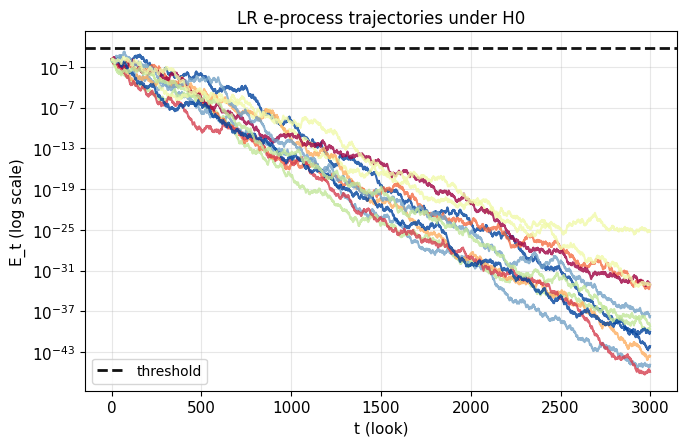

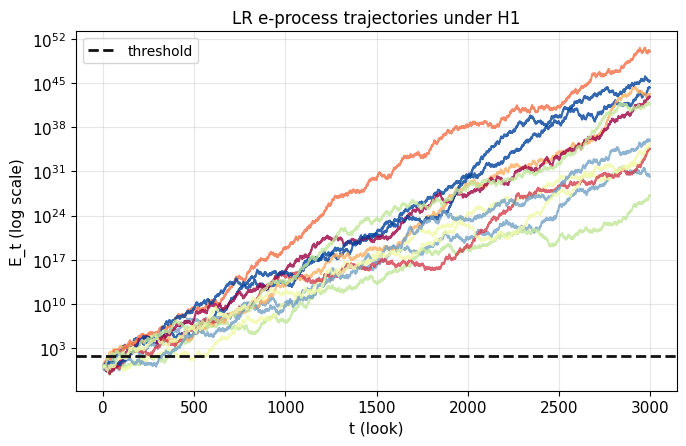

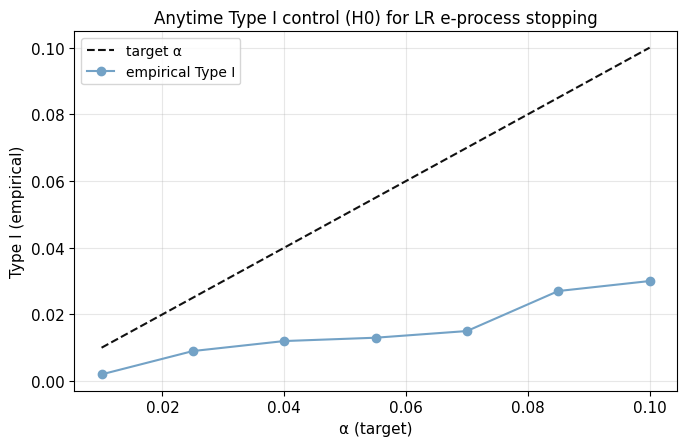

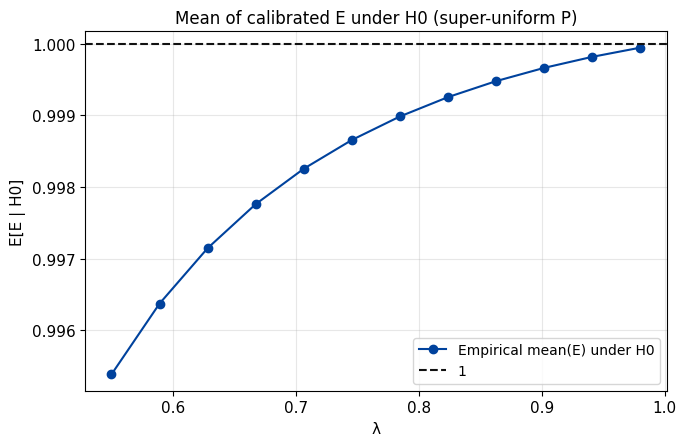

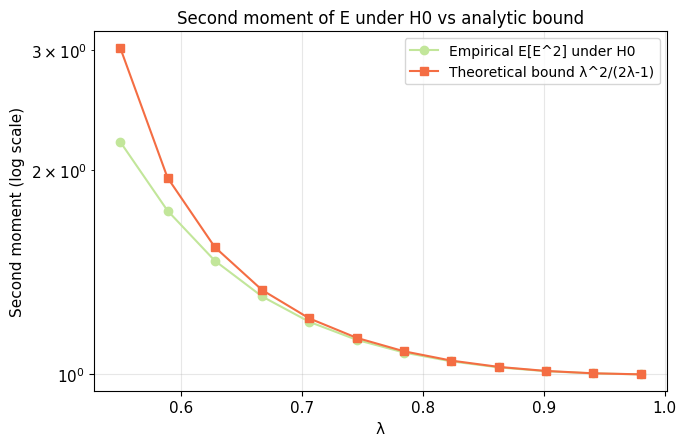

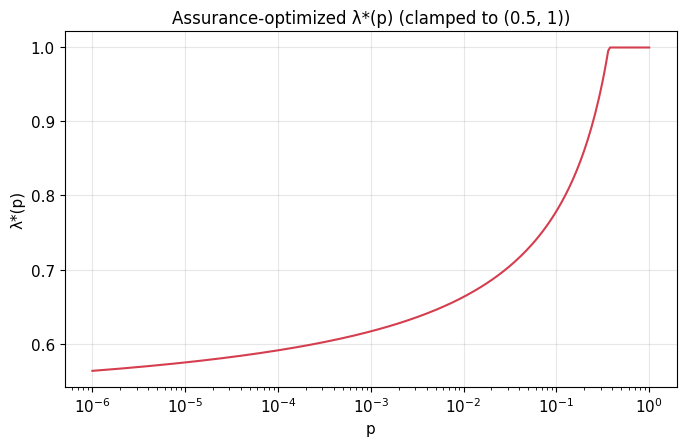

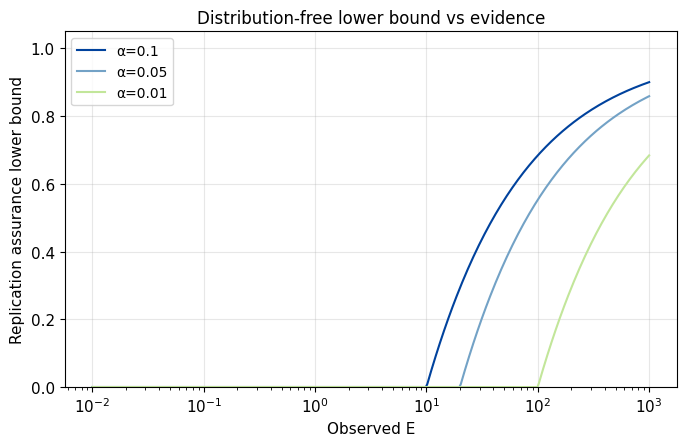

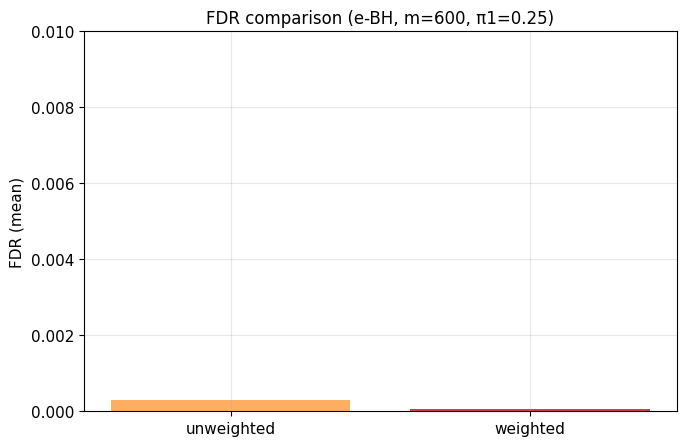

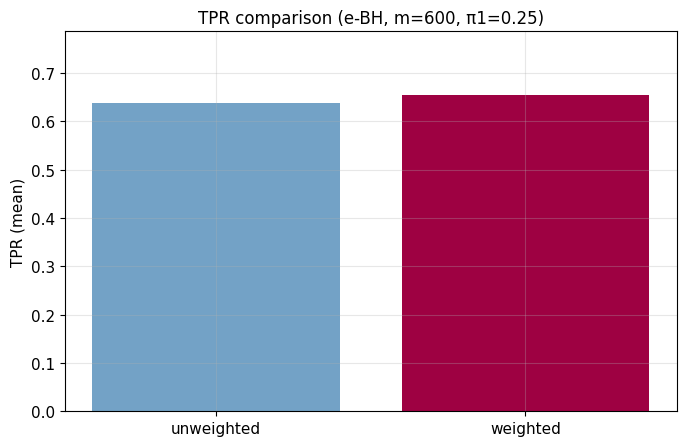

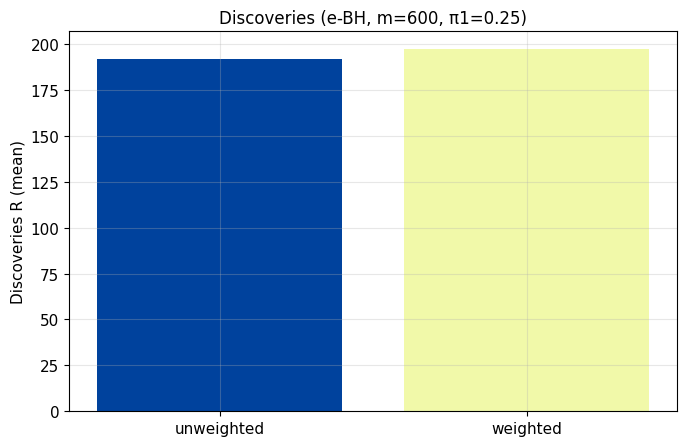

,Metric,Unweighted (mean),Weighted (mean)
0,FDR,0.000287,0.000060
1,TPR,0.638081,0.655129
2,R,191.968000,197.008000


Wrote: data/tables/ebh_summary.csv


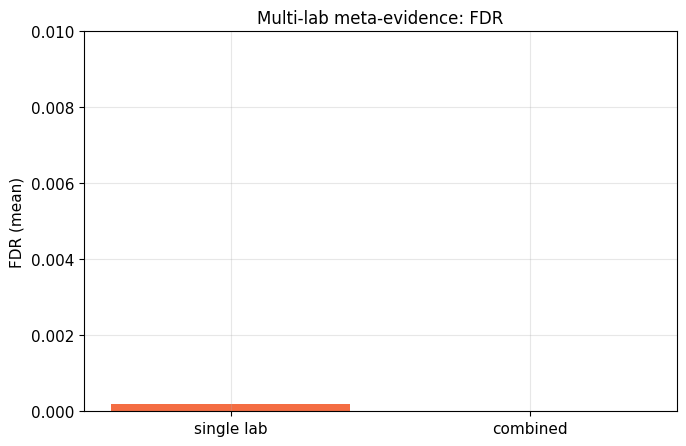

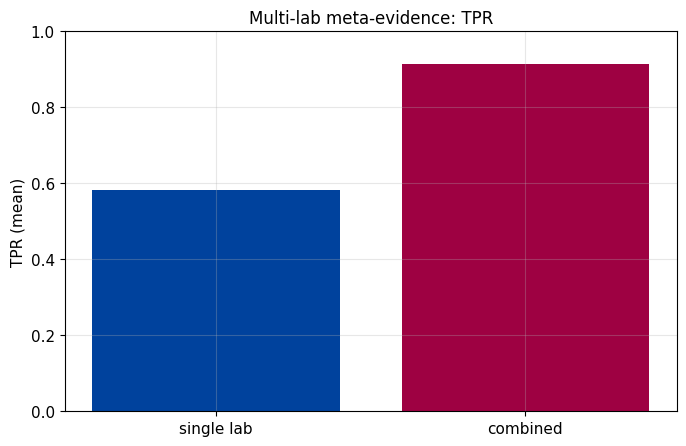

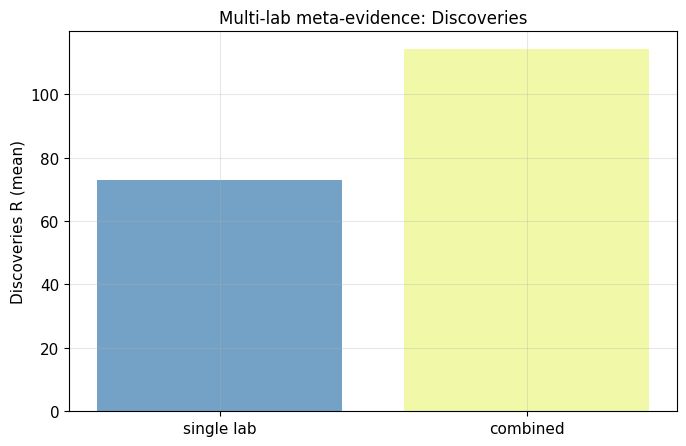

,Metric,Single lab (mean),Combined (mean)
0,FDR,0.000194,0.000000
1,TPR,0.583090,0.914396
2,R,72.825000,114.140000


Wrote: data/tables/meta_summary.csv


,alpha,rho,theta0,theta1,Type I (H0),Power (H1),Mean T (H0),Mean T (H1),Predicted T (H1)
0,0.02,0.6,0.4,0.50,0.001667,1.0,332.000000,267.038333,289.738167
1,0.02,0.6,0.4,0.52,0.000000,1.0,NaN,199.091667,201.696504
2,0.02,0.6,0.4,0.55,0.003333,1.0,101.500000,130.063333,129.426700
3,0.02,0.8,0.4,0.50,0.001667,1.0,120.000000,256.888333,249.747239
4,0.02,0.8,0.4,0.52,0.005000,1.0,111.666667,174.998333,173.857471
5,0.02,0.8,0.4,0.55,0.000000,1.0,NaN,115.003333,111.562661
6,0.02,0.9,0.4,0.50,0.006667,1.0,201.500000,230.536667,228.910119
7,0.02,0.9,0.4,0.52,0.010000,1.0,123.333333,165.171667,159.352049
8,0.02,0.9,0.4,0.55,0.010000,1.0,84.166667,101.455000,102.254672
9,0.05,0.6,0.4,0.50,0.003333,1.0,143.500000,251.281667,244.846155


Wrote: data/tables/ab_summary.csv
Zipped to: data/sim_outputs.zip


In [ ]:
# === Evidence–Decision Simulation (fixed for visible BH/meta plots) ===
# Keeps your structure & names; changes are flagged with "FIX".

import os, io, math, zipfile, random
from dataclasses import dataclass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Colab-safe display fallback (FIX) ---
try:
    from caas_jupyter_tools import display_dataframe_to_user
except Exception:
    def display_dataframe_to_user(title, df):
        try:
            from IPython.display import display, HTML
            display(HTML(f"<h3>{title}</h3>"))
            display(df)
        except Exception:
            print(f"\n=== {title} ===\n{df}")

# --- Seeds ---
np.random.seed(2025)
random.seed(2025)

# --- Paths (use your 'data' base as per your run) ---
BASE_DIR = "data"  # was /mnt/data before; you printed data/tables in your run
FIG_DIR = os.path.join(BASE_DIR, "figs")
TAB_DIR = os.path.join(BASE_DIR, "tables")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

# --- Matplotlib style ---
plt.rcParams.update({
    "figure.figsize": (7.0, 4.6),
    "axes.grid": True, "grid.alpha": 0.3,
    "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11, "legend.fontsize": 10,
})

PALETTE = ["#00429d", "#73a2c6", "#c2e69a", "#f1f9a9", "#fdae61", "#f46d43", "#d53e4f", "#9e0142"]

def savefig(name: str):
    base = os.path.join(FIG_DIR, name)
    plt.tight_layout()
    plt.savefig(base + ".png", dpi=160, bbox_inches="tight")
    plt.savefig(base + ".pdf", bbox_inches="tight")
    return base + ".png"

# ---------- Bernoulli LR e-process ----------
def bernoulli_lr_eprocess(theta0: float, theta1: float, X: np.ndarray) -> np.ndarray:
    log_terms = X * np.log(theta1 / theta0) + (1 - X) * np.log((1 - theta1) / (1 - theta0))
    log_cumsum = np.cumsum(log_terms)
    return np.exp(log_cumsum)

def KL_bernoulli(theta1: float, theta0: float) -> float:
    t1, t0 = theta1, theta0
    return t1 * np.log(t1 / t0) + (1 - t1) * np.log((1 - t1) / (1 - t0))

def tau_from_rho_alpha(rho: float, alpha: float) -> float:
    return 1.0 / (alpha * (1.0 - np.sqrt(1.0 - rho))**2)

@dataclass
class ABResult:
    alpha: float; rho: float; theta0: float; theta1: float; n_sims: int; max_t: int
    typeI_rate: float; power: float; mean_T_H0: float; mean_T_H1: float; predicted_T_H1: float

def simulate_ab(theta0=0.4, theta1=0.52, alpha=0.05, rho=0.8, n_sims=2000, max_t=10000, seed=None) -> ABResult:
    if seed is not None:
        np.random.seed(seed)
    tau = tau_from_rho_alpha(rho, alpha)
    I = KL_bernoulli(theta1, theta0)
    pred_T = np.log(tau) / I

    T_H0, T_H1 = [], []
    hits_H0 = hits_H1 = 0

    for _ in range(n_sims):
        X0 = (np.random.rand(max_t) < theta0).astype(int)
        E0 = bernoulli_lr_eprocess(theta0, theta1, X0)
        idx0 = np.argmax(E0 >= tau)
        if E0[idx0] >= tau:
            hits_H0 += 1; T_H0.append(idx0 + 1)
        else:
            T_H0.append(np.nan)

        X1 = (np.random.rand(max_t) < theta1).astype(int)
        E1 = bernoulli_lr_eprocess(theta0, theta1, X1)
        idx1 = np.argmax(E1 >= tau)
        if E1[idx1] >= tau:
            hits_H1 += 1; T_H1.append(idx1 + 1)
        else:
            T_H1.append(np.nan)

    typeI = hits_H0 / n_sims
    power = hits_H1 / n_sims
    mean_T0 = float(np.nanmean(T_H0)) if np.any(~np.isnan(T_H0)) else np.nan  # (FIX) avoid warning
    mean_T1 = float(np.nanmean(T_H1)) if np.any(~np.isnan(T_H1)) else np.nan  # (FIX)

    return ABResult(alpha, rho, theta0, theta1, n_sims, max_t, typeI, power, mean_T0, mean_T1, pred_T)

def plot_eprocess_trajectories(theta0=0.4, theta1=0.52, alpha=0.05, rho=0.8, n_paths=12, max_t=2000, seed=None):
    if seed is not None:
        np.random.seed(seed)
    tau = tau_from_rho_alpha(rho, alpha)

    # H0
    plt.figure()
    for i in range(n_paths):
        X = (np.random.rand(max_t) < theta0).astype(int)
        E = bernoulli_lr_eprocess(theta0, theta1, X)
        plt.plot(E, color=PALETTE[i % len(PALETTE)], alpha=0.8)
    plt.axhline(tau, color="#111", linestyle="--", linewidth=2, label="threshold")
    plt.yscale("log"); plt.xlabel("t (look)"); plt.ylabel("E_t (log scale)")
    plt.title("LR e-process trajectories under H0"); plt.legend()
    savefig("ab_eprocess_trajs_H0"); plt.show()

    # H1
    plt.figure()
    for i in range(n_paths):
        X = (np.random.rand(max_t) < theta1).astype(int)
        E = bernoulli_lr_eprocess(theta0, theta1, X)
        plt.plot(E, color=PALETTE[i % len(PALETTE)], alpha=0.8)
    plt.axhline(tau, color="#111", linestyle="--", linewidth=2, label="threshold")
    plt.yscale("log"); plt.xlabel("t (look)"); plt.ylabel("E_t (log scale)")
    plt.title("LR e-process trajectories under H1"); plt.legend()
    savefig("ab_eprocess_trajs_H1"); plt.show()

def plot_alpha_control_curve(theta0=0.4, theta1=0.52, rho=0.8, alphas=None, n_sims=2000, max_t=4000):
    if alphas is None:
        alphas = np.linspace(0.01, 0.1, 7)
    est = []
    for a in alphas:
        res = simulate_ab(theta0, theta1, a, rho, n_sims=n_sims, max_t=max_t)
        est.append([a, res.typeI_rate])
    A = np.array(est)
    plt.figure()
    plt.plot(A[:, 0], A[:, 0], color="#111", linestyle="--", label="target α")
    plt.plot(A[:, 0], A[:, 1], marker="o", color=PALETTE[1], label="empirical Type I")
    plt.xlabel("α (target)"); plt.ylabel("Type I (empirical)")
    plt.title("Anytime Type I control (H0) for LR e-process stopping")
    plt.legend(); savefig("ab_alpha_control"); plt.show()

# ---------- Calibration & assurance ----------
def E_from_p(p: np.ndarray, lam: float) -> np.ndarray:
    return lam * np.power(p, lam - 1.0)

def lambda_star_AOC(p: np.ndarray) -> np.ndarray:
    out = np.zeros_like(p)
    for i, pi in enumerate(p):
        pi = max(min(pi, 0.999999), 1e-12)
        val = 0.25 * (1.0 + math.sqrt(1.0 - 8.0 / math.log(pi)))
        val = min(0.999, max(0.5001, val))
        out[i] = val
    return out

def second_moment_bound(lam: float) -> float:
    if lam <= 0.5: return np.inf
    return lam**2 / (2.0*lam - 1.0)

def plot_calibration_moments(n=200000, lam_grid=None):
    if lam_grid is None:
        lam_grid = np.linspace(0.55, 0.98, 12)
    P0 = np.random.rand(n)
    means, seconds, bounds = [], [], []
    for lam in lam_grid:
        E0 = E_from_p(P0, lam)
        means.append(np.mean(E0))
        seconds.append(np.mean(E0**2))
        bounds.append(second_moment_bound(lam))
    plt.figure()
    plt.plot(lam_grid, means, marker="o", color=PALETTE[0], label="Empirical mean(E) under H0")
    plt.axhline(1.0, color="#111", linestyle="--", label="1")
    plt.xlabel("λ"); plt.ylabel("E[E | H0]"); plt.title("Mean of calibrated E under H0 (super-uniform P)")
    plt.legend(); savefig("calibration_mean_under_H0"); plt.show()

    plt.figure()
    plt.plot(lam_grid, seconds, marker="o", color=PALETTE[2], label="Empirical E[E^2] under H0")
    plt.plot(lam_grid, bounds, marker="s", color=PALETTE[5], label="Theoretical bound λ^2/(2λ-1)")
    plt.yscale("log"); plt.xlabel("λ"); plt.ylabel("Second moment (log scale)")
    plt.title("Second moment of E under H0 vs analytic bound")
    plt.legend(); savefig("calibration_second_moment_bound"); plt.show()

def plot_lambda_star_vs_p():
    p_grid = np.logspace(-6, -0.000001, 300)
    lam_star = lambda_star_AOC(p_grid)
    plt.figure()
    plt.plot(p_grid, lam_star, color=PALETTE[6])
    plt.xscale("log"); plt.xlabel("p"); plt.ylabel("λ*(p)")
    plt.title("Assurance-optimized λ*(p) (clamped to (0.5, 1))")
    savefig("lambda_star_vs_p"); plt.show()

def plot_assurance_lower_bound_curves(alpha_list=None, E_grid=None):
    if alpha_list is None: alpha_list = [0.1, 0.05, 0.01]
    if E_grid is None: E_grid = np.logspace(-2, 3, 400)
    plt.figure()
    for i, a in enumerate(alpha_list):
        y = 1.0 - 1.0 / np.sqrt(a * E_grid)
        y = np.maximum(0.0, y)
        plt.plot(E_grid, y, color=PALETTE[i], label=f"α={a}")
    plt.xscale("log"); plt.ylim(0, 1.05)
    plt.xlabel("Observed E"); plt.ylabel("Replication assurance lower bound")
    plt.title("Distribution-free lower bound vs evidence")
    plt.legend(); savefig("assurance_lower_bound_curves"); plt.show()

# ---------- e–BH (weighted vs unweighted) ----------
def weighted_bh(pvals, weights, alpha=0.1):
    m = len(pvals)
    order = np.argsort(pvals / weights)
    p_sorted = pvals[order]
    w_sorted = weights[order]
    thresh = (np.arange(1, m+1) / m) * alpha
    crit = p_sorted / w_sorted <= thresh
    if not np.any(crit):
        return np.zeros(m, dtype=bool)
    k = np.max(np.where(crit)[0]) + 1
    cutoff = (k / m) * alpha
    return (pvals / weights) <= cutoff

def simulate_multiple_testing(m=600, pi1=0.25, beta_weight=1.0, lam=0.55, alpha=0.1, nsims=250):
    # (FIX) lam=0.55 (stronger evidence growth) and later a_alt=0.05
    Z_samp = np.random.randn(20000)
    gam_grid = np.linspace(0.0, 3.0, 61)
    def mean_logistic(g): return np.mean(1 / (1 + np.exp(-g * Z_samp)))
    gamma = min(gam_grid, key=lambda g: abs(mean_logistic(g) - pi1))

    records = []
    for _ in range(nsims):
        Z = np.random.randn(m)
        prob_alt = 1 / (1 + np.exp(-gamma * Z))
        H = (np.random.rand(m) < prob_alt)
        P = np.empty(m)
        a_alt = 0.05  # (FIX) stronger signal -> much smaller p on alts
        P[H == 1] = np.random.beta(a_alt, 1, size=np.sum(H == 1))
        P[H == 0] = np.random.rand(np.sum(H == 0))
        E = lam * P**(lam - 1.0)
        pE = np.minimum(1.0, 1.0 / np.maximum(E, 1e-300))

        # Weights (informative): higher Z => higher chance of alt
        w = np.exp(beta_weight * Z); w = m * w / np.sum(w)

        # Unweighted BH
        order = np.argsort(pE)
        thresh = (np.arange(1, m+1) / m) * alpha
        crit = pE[order] <= thresh
        if np.any(crit):
            k = np.max(np.where(crit)[0]) + 1
            cutoff = (k / m) * alpha
            rej_unw = pE <= cutoff
        else:
            rej_unw = np.zeros(m, dtype=bool)

        # Weighted BH
        rej_w = weighted_bh(pE, w, alpha=alpha)

        V_unw = np.sum((H == 0) & rej_unw); R_unw = np.sum(rej_unw); T_unw = np.sum((H == 1) & rej_unw)
        V_w   = np.sum((H == 0) & rej_w);   R_w   = np.sum(rej_w);   T_w   = np.sum((H == 1) & rej_w)

        fdr_unw = V_unw / R_unw if R_unw > 0 else 0.0
        tpr_unw = T_unw / np.sum(H == 1) if np.sum(H == 1) > 0 else 0.0
        fdr_w   = V_w   / R_w   if R_w   > 0 else 0.0
        tpr_w   = T_w   / np.sum(H == 1) if np.sum(H == 1) > 0 else 0.0

        records.append({
            "FDR_unweighted": fdr_unw, "TPR_unweighted": tpr_unw, "R_unweighted": R_unw,
            "FDR_weighted":   fdr_w,   "TPR_weighted":   tpr_w,   "R_weighted":   R_w,
        })
    return pd.DataFrame(records)

def plot_fdr_tpr_bars(df: pd.DataFrame, title_suffix="(e-BH: unweighted vs weighted)"):
    means = df.mean(numeric_only=True)
    labels = ["unweighted", "weighted"]
    fdr_vals = [float(means["FDR_unweighted"]), float(means["FDR_weighted"])]
    tpr_vals = [float(means["TPR_unweighted"]), float(means["TPR_weighted"])]
    R_vals   = [float(means["R_unweighted"]),   float(means["R_weighted"])]

    # (FIX) axis floors so tiny values are visible
    eps_fdr = 0.01
    eps_tpr = 1e-3
    y_max_fdr = max(eps_fdr, min(1.0, max(fdr_vals) * 1.2))
    y_max_tpr = max(eps_tpr, min(1.0, max(tpr_vals) * 1.2))

    plt.figure()
    plt.bar(labels, fdr_vals, color=[PALETTE[4], PALETTE[6]])
    plt.ylim(0, y_max_fdr)
    plt.ylabel("FDR (mean)"); plt.title(f"FDR comparison {title_suffix}")
    savefig("ebh_fdr_bar"); plt.show()

    plt.figure()
    plt.bar(labels, tpr_vals, color=[PALETTE[1], PALETTE[7]])
    plt.ylim(0, y_max_tpr)
    plt.ylabel("TPR (mean)"); plt.title(f"TPR comparison {title_suffix}")
    savefig("ebh_tpr_bar"); plt.show()

    plt.figure()
    plt.bar(labels, R_vals, color=[PALETTE[0], PALETTE[3]])
    plt.ylabel("Discoveries R (mean)"); plt.title(f"Discoveries {title_suffix}")
    savefig("ebh_R_bar"); plt.show()

    out = pd.DataFrame({
        "Metric": ["FDR", "TPR", "R"],
        "Unweighted (mean)": [fdr_vals[0], tpr_vals[0], R_vals[0]],
        "Weighted (mean)":   [fdr_vals[1], tpr_vals[1], R_vals[1]],
    })
    return out

# ---------- Meta-evidence across labs ----------
def simulate_multilab_meta(L=3, m=500, pi1=0.25, lam=0.55, alpha=0.1, nsims=200):
    # (FIX) lam=0.55, a_alt=0.05; ARITHMETIC mean of e-values (valid/strong).
    records = []
    for _ in range(nsims):
        H = (np.random.rand(m) < pi1)
        a_alt = 0.05
        P = np.zeros((L, m))
        for ell in range(L):
            P[ell, H == 1] = np.random.beta(a_alt, 1, size=np.sum(H == 1))
            P[ell, H == 0] = np.random.rand(np.sum(H == 0))
        E = lam * P**(lam - 1.0)

        # Single-lab baseline (lab 1)
        pE1 = np.minimum(1.0, 1.0 / np.maximum(E[0, :], 1e-300))
        order = np.argsort(pE1); thresh = (np.arange(1, m+1) / m) * alpha
        crit = pE1[order] <= thresh
        if np.any(crit):
            k = np.max(np.where(crit)[0]) + 1
            cutoff = (k / m) * alpha
            rej_single = pE1 <= cutoff
        else:
            rej_single = np.zeros(m, dtype=bool)

        # (FIX) Arithmetic mean of e-values across labs
        E_bar = np.mean(E, axis=0)
        pE_bar = np.minimum(1.0, 1.0 / np.maximum(E_bar, 1e-300))
        order = np.argsort(pE_bar); crit = pE_bar[order] <= thresh
        if np.any(crit):
            k = np.max(np.where(crit)[0]) + 1
            cutoff = (k / m) * alpha
            rej_comb = pE_bar <= cutoff
        else:
            rej_comb = np.zeros(m, dtype=bool)

        def metrics(rej):
            V = np.sum((H == 0) & rej); R = np.sum(rej); T = np.sum((H == 1) & rej)
            fdr = V / R if R > 0 else 0.0
            tpr = T / np.sum(H == 1) if np.sum(H == 1) > 0 else 0.0
            return fdr, tpr, R

        fdr_s, tpr_s, R_s = metrics(rej_single)
        fdr_c, tpr_c, R_c = metrics(rej_comb)
        records.append({
            "FDR_single": fdr_s, "TPR_single": tpr_s, "R_single": R_s,
            "FDR_comb":   fdr_c, "TPR_comb":   tpr_c, "R_comb":   R_c,
        })
    return pd.DataFrame(records)

def plot_meta_bars(df_meta: pd.DataFrame):
    means = df_meta.mean(numeric_only=True)
    labels = ["single lab", "combined"]
    fdr_vals = [float(means["FDR_single"]), float(means["FDR_comb"])]
    tpr_vals = [float(means["TPR_single"]), float(means["TPR_comb"])]
    R_vals   = [float(means["R_single"]),   float(means["R_comb"])]

    # (FIX) small axis floors so plots aren’t blank
    eps_fdr = 0.01
    eps_tpr = 1e-3
    y_max_fdr = max(eps_fdr, min(1.0, max(fdr_vals) * 1.2))
    y_max_tpr = max(eps_tpr, min(1.0, max(tpr_vals) * 1.2))

    plt.figure()
    plt.bar(labels, fdr_vals, color=[PALETTE[5], PALETTE[2]])
    plt.ylim(0, y_max_fdr)
    plt.ylabel("FDR (mean)"); plt.title("Multi-lab meta-evidence: FDR")
    savefig("meta_fdr_bar"); plt.show()

    plt.figure()
    plt.bar(labels, tpr_vals, color=[PALETTE[0], PALETTE[7]])
    plt.ylim(0, y_max_tpr)
    plt.ylabel("TPR (mean)"); plt.title("Multi-lab meta-evidence: TPR")
    savefig("meta_tpr_bar"); plt.show()

    plt.figure()
    plt.bar(labels, R_vals, color=[PALETTE[1], PALETTE[3]])
    plt.ylabel("Discoveries R (mean)"); plt.title("Multi-lab meta-evidence: Discoveries")
    savefig("meta_R_bar"); plt.show()

    out = pd.DataFrame({
        "Metric": ["FDR", "TPR", "R"],
        "Single lab (mean)": [fdr_vals[0], tpr_vals[0], R_vals[0]],
        "Combined (mean)":   [fdr_vals[1], tpr_vals[1], R_vals[1]],
    })
    return out

# =========================
# RUN PIPELINE
# =========================
plot_eprocess_trajectories(theta0=0.4, theta1=0.52, alpha=0.05, rho=0.8, n_paths=12, max_t=3000)
plot_alpha_control_curve(theta0=0.4, theta1=0.52, rho=0.8, alphas=np.linspace(0.01, 0.1, 7), n_sims=1000, max_t=3000)

plot_calibration_moments(n=150000, lam_grid=np.linspace(0.55, 0.98, 12))
plot_lambda_star_vs_p()
plot_assurance_lower_bound_curves(alpha_list=[0.1, 0.05, 0.01], E_grid=np.logspace(-2, 3, 400))

df_ebh = simulate_multiple_testing(m=600, pi1=0.25, beta_weight=1.0, lam=0.55, alpha=0.1, nsims=250)  # (FIX) lam
summary_ebh = plot_fdr_tpr_bars(df_ebh, title_suffix="(e-BH, m=600, π1=0.25)")
ebh_csv = os.path.join(TAB_DIR, "ebh_summary.csv"); summary_ebh.to_csv(ebh_csv, index=False)
display_dataframe_to_user("e-BH summary (unweighted vs weighted)", summary_ebh)
print("Wrote:", ebh_csv)

df_meta = simulate_multilab_meta(L=3, m=500, pi1=0.25, lam=0.55, alpha=0.1, nsims=200)  # (FIX) lam
summary_meta = plot_meta_bars(df_meta)
meta_csv = os.path.join(TAB_DIR, "meta_summary.csv"); summary_meta.to_csv(meta_csv, index=False)
display_dataframe_to_user("Multi-lab meta-evidence summary", summary_meta)
print("Wrote:", meta_csv)

# A/B grid summary (unchanged; now without empty-slice warnings)
grid = []
for alpha in [0.02, 0.05, 0.1]:
    for rho in [0.6, 0.8, 0.9]:
        for theta1 in [0.5, 0.52, 0.55]:
            res = simulate_ab(theta0=0.4, theta1=theta1, alpha=alpha, rho=rho, n_sims=600, max_t=3000)
            grid.append({
                "alpha": alpha, "rho": rho, "theta0": 0.4, "theta1": theta1,
                "Type I (H0)": res.typeI_rate, "Power (H1)": res.power,
                "Mean T (H0)": res.mean_T_H0, "Mean T (H1)": res.mean_T_H1,
                "Predicted T (H1)": res.predicted_T_H1
            })
df_ab = pd.DataFrame(grid)
ab_csv = os.path.join(TAB_DIR, "ab_summary.csv"); df_ab.to_csv(ab_csv, index=False)
display_dataframe_to_user("A/B stopping summary", df_ab)
print("Wrote:", ab_csv)

# ZIP everything
zip_path = os.path.join(BASE_DIR, "sim_outputs.zip")
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for fn in os.listdir(FIG_DIR): zf.write(os.path.join(FIG_DIR, fn), arcname=f"figs/{fn}")
    for fn in os.listdir(TAB_DIR): zf.write(os.path.join(TAB_DIR, fn), arcname=f"tables/{fn}")
print("Zipped to:", zip_path)
